<a href="https://colab.research.google.com/github/EarlyOcean/CVL_Assignment02/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteksi buah persik dengan segmentasi warna

Deteksi memanfaatkan fitur warna buah persik yang mayoritas merah. Citra yang akan dideteksi merupakan gambar pohon persik yang sudah berbuah.

In [76]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

!rm -rf CVL_Assignment02
!git clone https://github.com/EarlyOcean/CVL_Assignment02

Cloning into 'CVL_Assignment02'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 23 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 238.85 KiB | 1.68 MiB/s, done.
Resolving deltas: 100% (3/3), done.


Citra asli


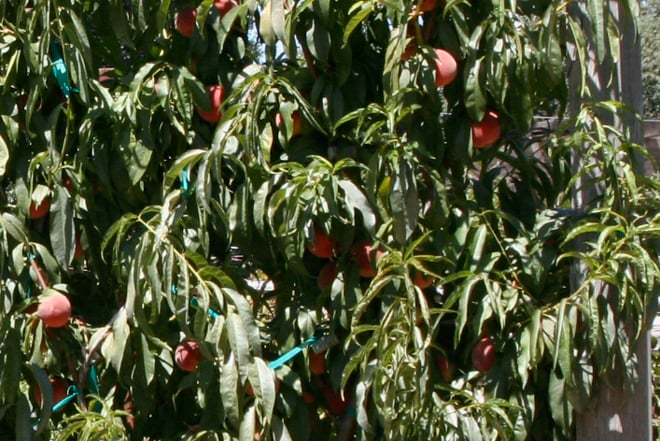

In [103]:
original_img = cv2.imread("/content/CVL_Assignment02/peach.jpg")

print("Citra asli")
cv2_imshow(original_img)

# Segmentasi

Segmentasi menggunakan nilai threshold global. Warna merah didefinisikan sebagai kombinasi nilai rgb, dimana r lebih besar dari g dan b setidaknya 20 satuan.

Citra threshold


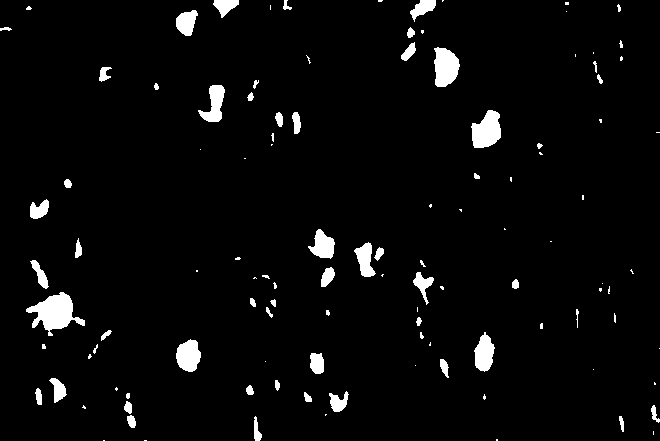

In [104]:
def is_red(r, g, b):
  r, g, b = int(r), int(g), int(b)
  #return r > b and r > g
  return (r - g > 20) and (r - b > 20)

img_array = np.array(original_img)
img_thresholded = np.zeros_like(img_array)

for i in range(img_array.shape[0]):        # height
    for j in range(img_array.shape[1]):    # width
        b, g, r = img_array[i, j]
        if is_red(r, g, b):
            img_thresholded[i, j] = 255
        else:
            img_thresholded[i, j] = 0


print("Citra threshold")
cv2_imshow(img_thresholded)

#

# Morfologi

Citra yang sudah di threshold diberlakukan proses morfologi opening untuk menghapus artifak-artifak yang muncul. Hasil dari tahap ini lah yang menjadi ROI.

In [71]:
kernel = np.ones((7, 7), dtype=np.uint8)

def dilate(img, kernel):
    h, w = img.shape[:2]
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2

    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    out = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            if np.any(region[kernel == 1] == 255):
                out[i, j] = 255
    return out

def erode(img, kernel):
    h, w = img.shape[:2]
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2

    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    out = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            if np.all(region[kernel == 1] == 255):
                out[i, j] = 255
    return out

def opening(img, kernel):
    return dilate(erode(img, kernel), kernel)

Citra opening


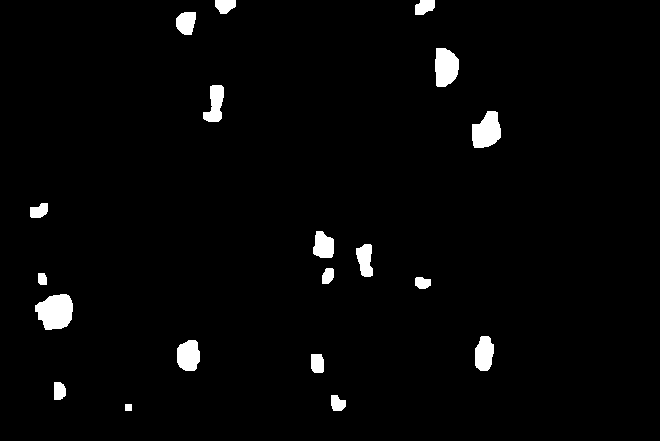

In [105]:
img_closed = opening(img_thresholded[:,:,0], kernel)
print("Citra opening")
cv2_imshow(img_closed)

Berikut perbandingan ROI pada citra asli.

ROI pada citra asli


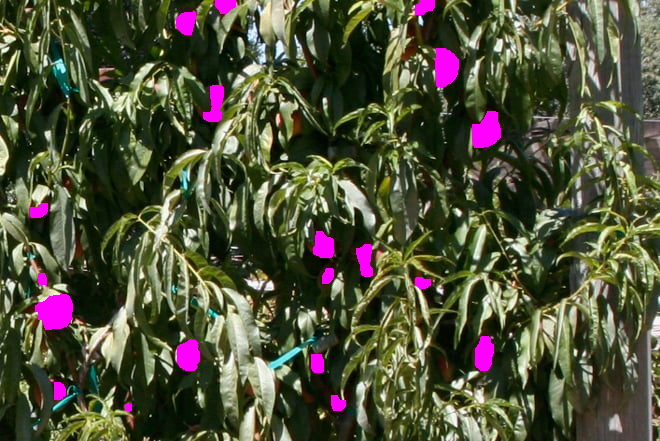

In [107]:
detect_img = np.array(original_img)

for i in range(img_closed.shape[0]):        # height
    for j in range(img_closed.shape[1]):    # width
        if img_closed[i, j] == 255:
            detect_img[i, j] = [255, 0, 255]

print("ROI pada citra asli")
cv2_imshow(detect_img)

# Evaluasi

Evaluasi dilakukan dengan membandingkan hasil deteksi dengan ground truth yang telah dibuat secara manual.

Citra ground truth


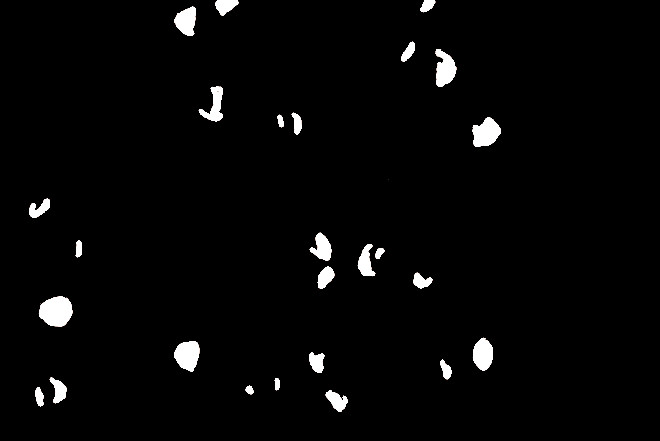

Ground truth pada citra asli


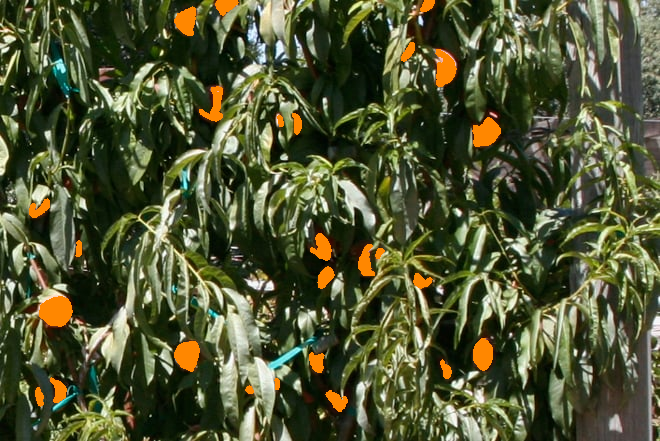

In [109]:
ground_truth = cv2.imread("/content/CVL_Assignment02/peach_ground_truth.jpg")

print("Citra ground truth")
cv2_imshow(ground_truth)

ground_truth_array = np.array(ground_truth)
ground_truth_color = np.array(original_img)

for i in range(ground_truth.shape[0]):        # height
    for j in range(ground_truth_array.shape[1]):    # width
        b, g, r = ground_truth_array[i, j]
        if b > 200 and g > 200 and r > 200:
            ground_truth_color[i, j] = [0, 135, 255]

print("Ground truth pada citra asli")
cv2_imshow(ground_truth_color)

Karena hasil dari deteksi merupakan ROI, evaluasi akan dilakukan menggunakan nilai IoU. Metode dapat dikembangkan lebih lanjut apabila hasil yang diinginkan adalah jumlah dari buah yang terdeteksi, dengan mengingat bahwa besar area buah dapat bervariasi dikarenakan jarak ataupun tertutup dedaunan.

Oranye = ground truth
Pink = deteksi
Biru = interseksi


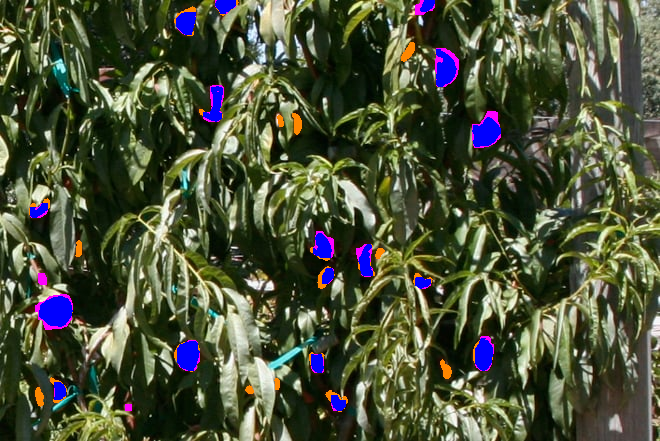

Intersect: 5663 pixels
Union: 8861 pixels
IoU: 0.6390926531994131


In [111]:
intersect_img = np.array(original_img)

intersect_val = 0
union_val = 0

for i in range(ground_truth.shape[0]):        # height
    for j in range(ground_truth_array.shape[1]):    # width
        b, g, r = ground_truth_array[i, j]

        is_ground_truth = b > 200 and g > 200 and r > 200
        is_detection = img_closed[i, j] == 255

        if is_ground_truth and is_detection:
            intersect_img[i, j] = [255, 0, 0]
            intersect_val += 1
            union_val += 1
        elif is_ground_truth:
            intersect_img[i, j] = [0, 135, 255]
            union_val += 1
        elif is_detection:
            intersect_img[i, j] = [255, 0, 255]
            union_val += 1

print("Oranye = ground truth\nPink = deteksi\nBiru = interseksi")
cv2_imshow(intersect_img)
print(f"Intersect: {intersect_val} pixels")
print(f"Union: {union_val} pixels")
print(f"IoU: {intersect_val / union_val}")